# Exploratory Data Analysis (EDA) on Financials_cleaned.csv

In this notebook, we perform Exploratory Data Analysis (EDA) on the cleaned Financials dataset.
We will:
- Load the cleaned data.
- Explore categorical variables (distributions).
- Explore numeric variables via histograms.
- Visualize profit by segment and total sales by country.
- Analyze sales and profit evolution over time.
- Create scatter plots, boxplots, and a correlation matrix with numeric values.
- Display additional plots such as a combined line chart (sales and profit over time), and various heatmaps with annotated values.

Let's begin!


## Step 1 – Load the Cleaned Dataset

We load the cleaned dataset from the `data/processed/` folder.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# Adjust the path if needed; if this notebook is in GET/notebooks, use "../data/processed/Financials_cleaned.csv"
data_path = os.path.join('..', 'data', 'processed', 'Financials_cleaned.csv')
df = pd.read_csv(data_path)

# Quick check on the dataset
print("DataFrame loaded with shape:", df.shape)
print(df.info())


DataFrame loaded with shape: (700, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   segment              700 non-null    object 
 1   country              700 non-null    object 
 2   product              700 non-null    object 
 3   discount_band        700 non-null    object 
 4   units_sold           700 non-null    float64
 5   manufacturing_price  700 non-null    float64
 6   sale_price           700 non-null    float64
 7   gross_sales          700 non-null    float64
 8   discounts            700 non-null    float64
 9   sales                700 non-null    float64
 10  cogs                 700 non-null    float64
 11  profit               700 non-null    float64
 12  date                 0 non-null      float64
 13  month_number         700 non-null    int64  
 14  month_name           700 non-null    object 
 15  y

## Step 2 – Analyze Categorical Variables

We will analyze the distribution of several categorical variables such as:
- `segment`
- `country`
- `product`
- `discount_band`


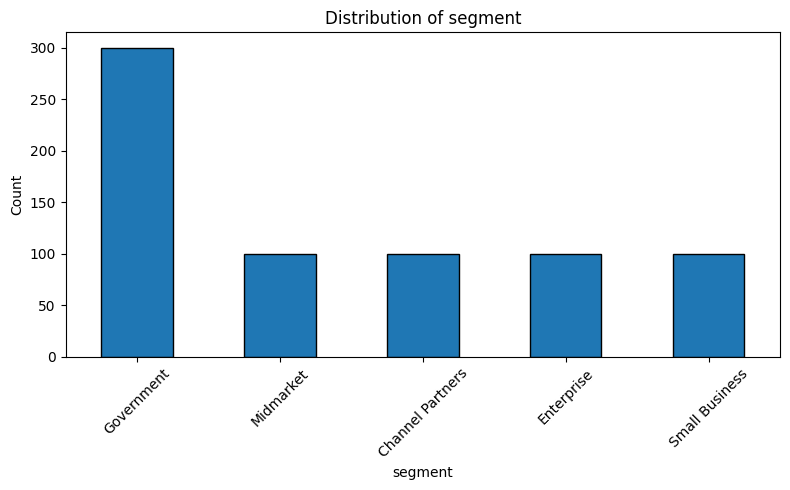

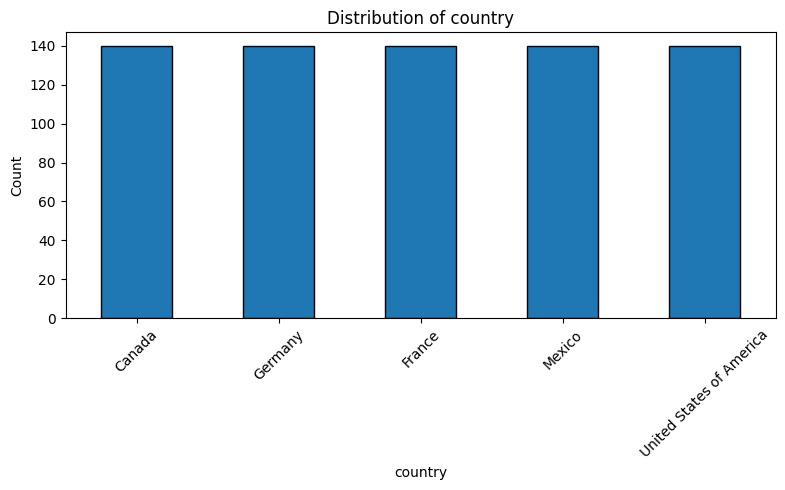

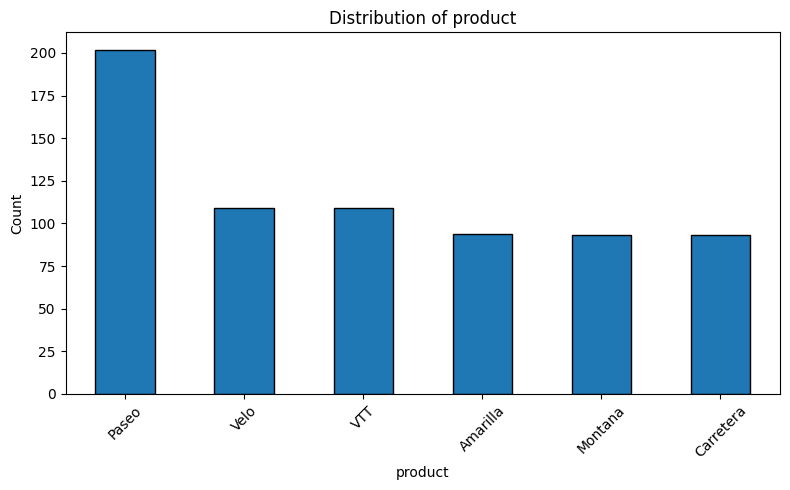

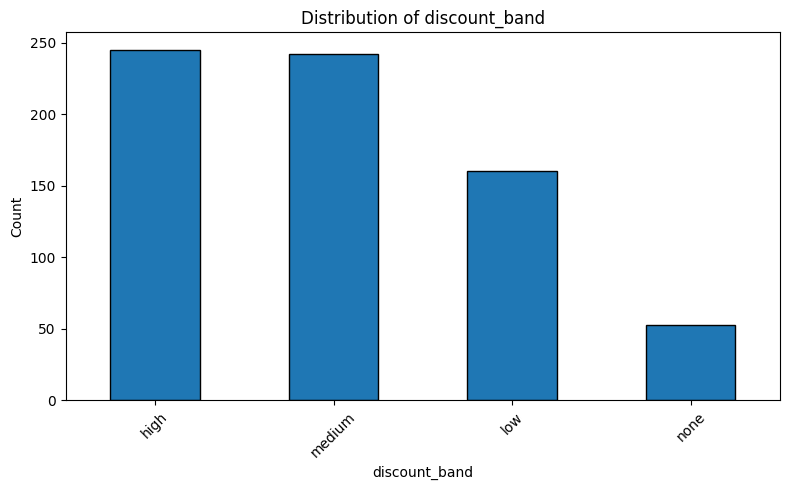

In [4]:
cat_cols = ['segment', 'country', 'product', 'discount_band']

for col in cat_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        df[col].value_counts(dropna=False).plot(kind='bar', edgecolor='k')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


## Step 3 – Distribution of Numeric Variables

We'll plot histograms for numeric variables to examine their distributions.


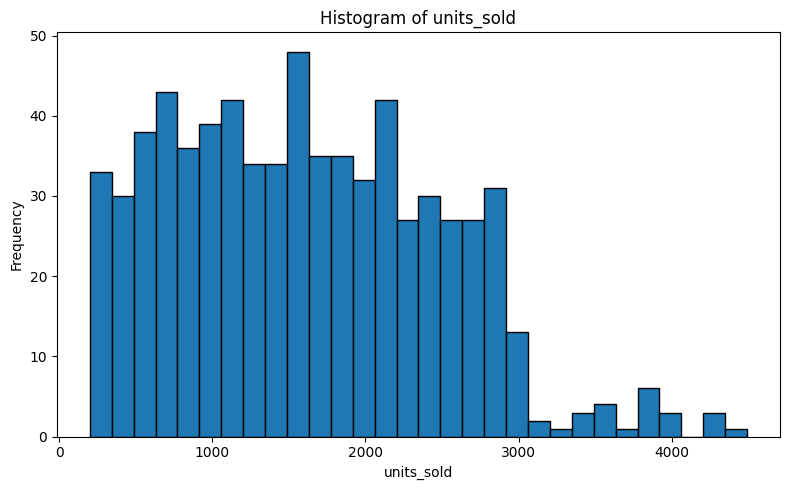

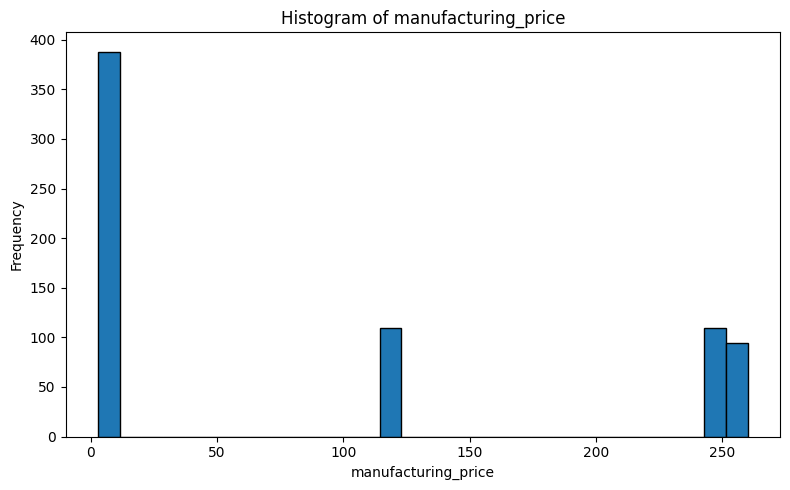

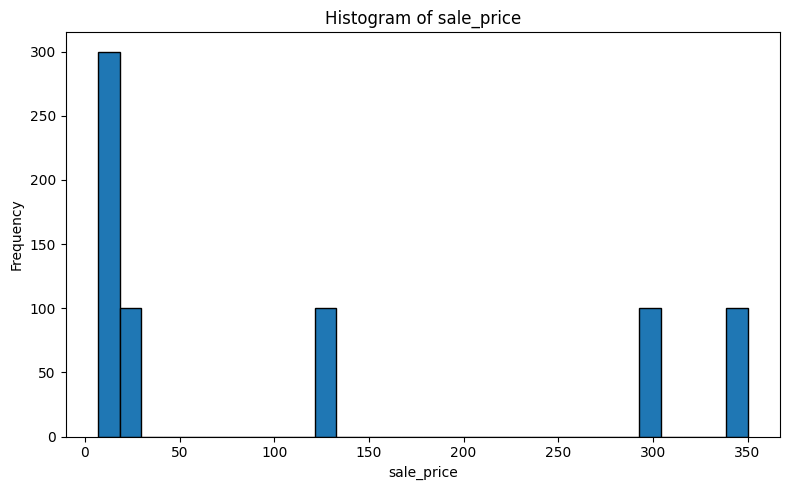

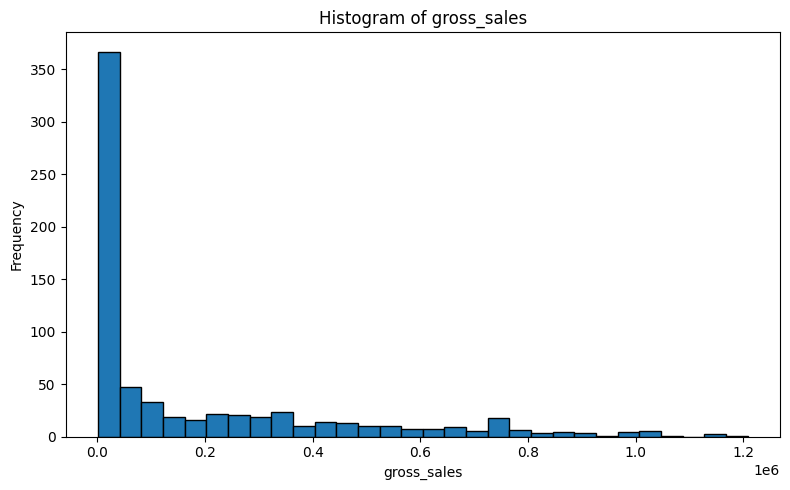

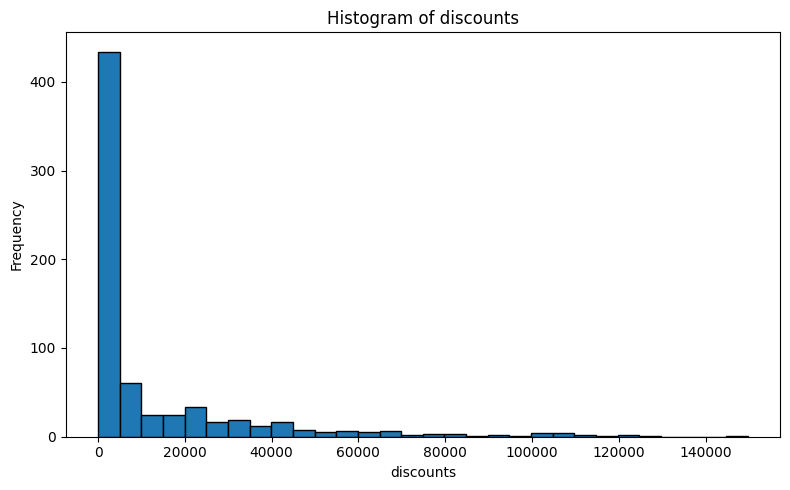

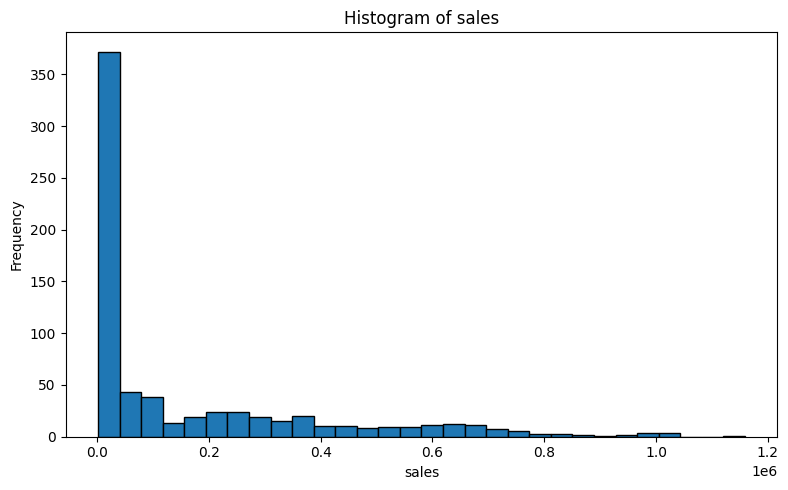

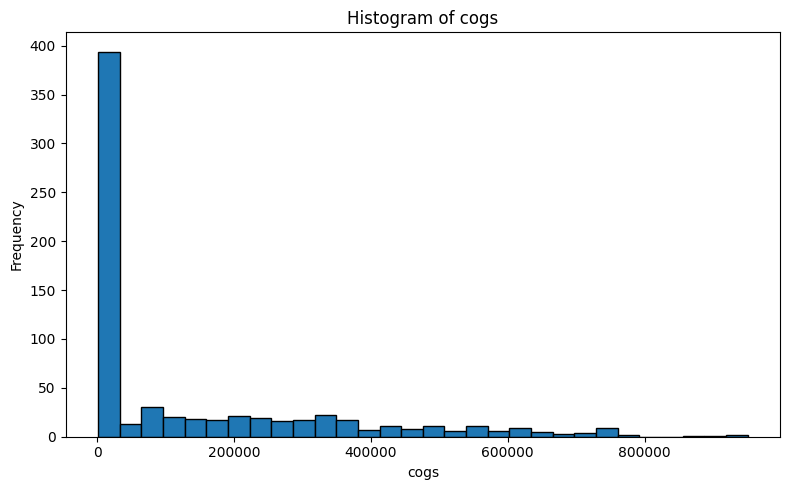

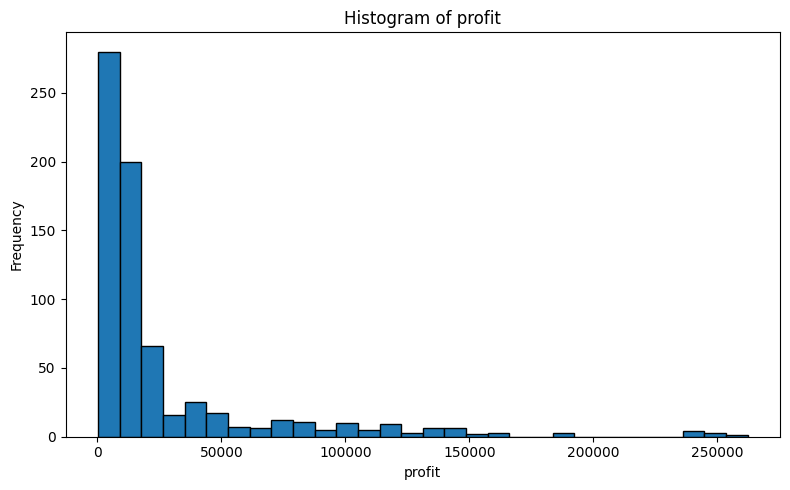

In [5]:
numeric_columns = [
    'units_sold', 
    'manufacturing_price', 
    'sale_price', 
    'gross_sales',
    'discounts', 
    'sales', 
    'cogs', 
    'profit'
]

for col in numeric_columns:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        plt.hist(df[col].dropna(), bins=30, edgecolor='k')
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()


## Step 4 – Bar Chart: Average Profit by Segment

This chart shows the average profit for each segment.


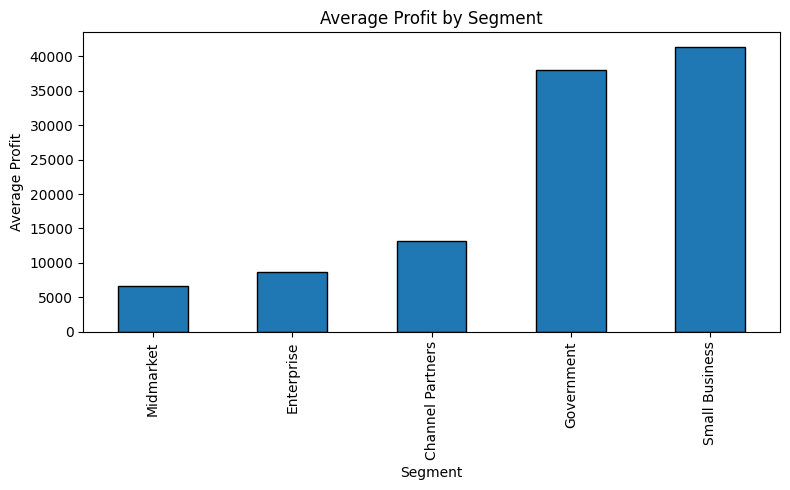

In [6]:
if 'segment' in df.columns and 'profit' in df.columns:
    mean_profit_by_segment = df.groupby('segment')['profit'].mean().sort_values()
    plt.figure(figsize=(8, 5))
    mean_profit_by_segment.plot(kind='bar', edgecolor='k')
    plt.title('Average Profit by Segment')
    plt.xlabel('Segment')
    plt.ylabel('Average Profit')
    plt.tight_layout()
    plt.show()


## Step 5 – Bar Chart: Total Sales by Country (Top 10)

This chart displays the top 10 countries by total sales.


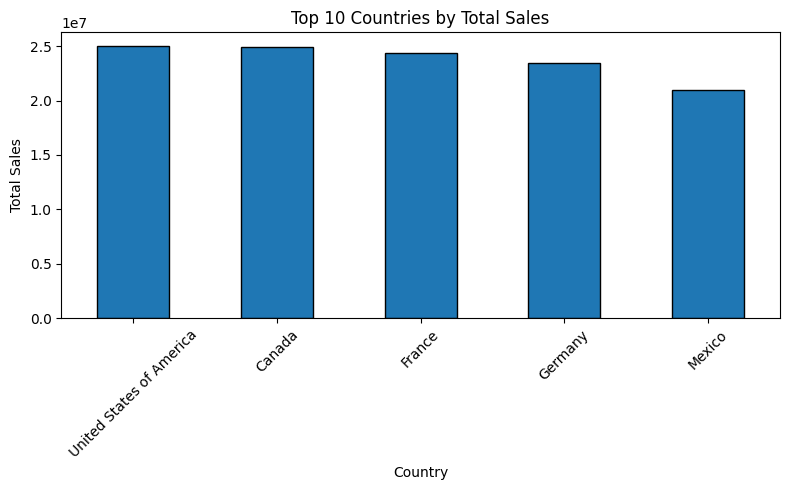

In [7]:
if 'country' in df.columns and 'sales' in df.columns:
    total_sales_by_country = df.groupby('country')['sales'].sum().sort_values(ascending=False)
    top_10 = total_sales_by_country.head(10)
    plt.figure(figsize=(8, 5))
    top_10.plot(kind='bar', edgecolor='k')
    plt.title('Top 10 Countries by Total Sales')
    plt.xlabel('Country')
    plt.ylabel('Total Sales')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Step 6 – Evolution of Sales and Profit Over Time (Bar Charts)

We will plot the total sales and total profit per year.


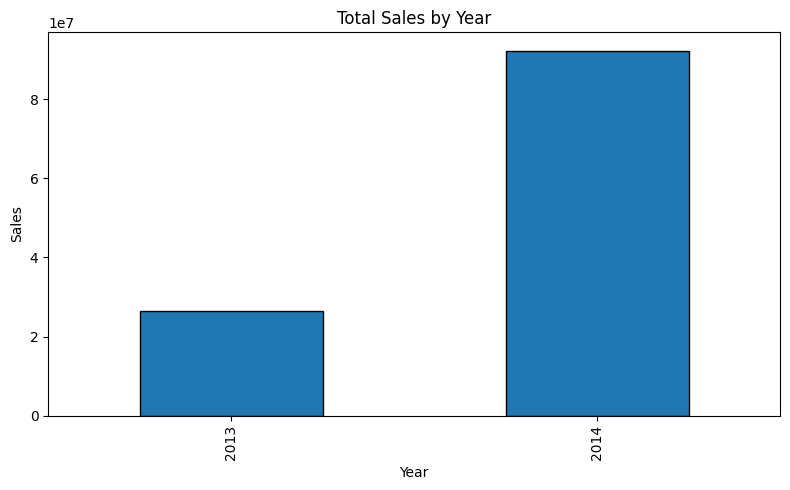

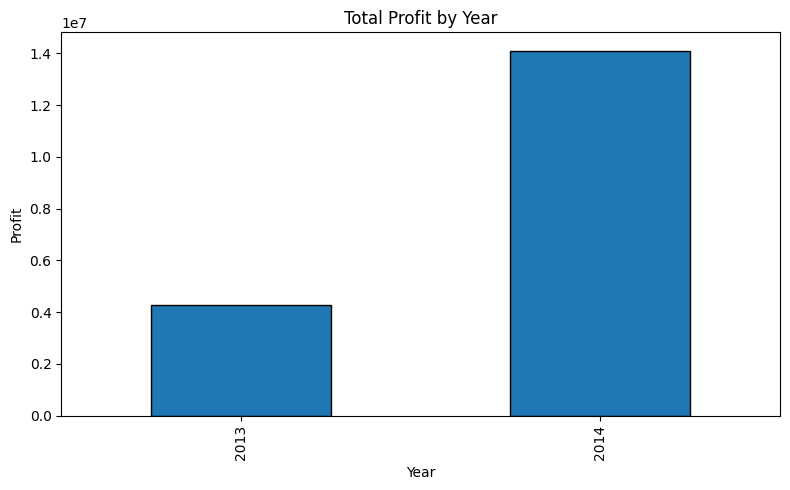

In [8]:
if 'year' in df.columns and 'sales' in df.columns:
    sales_by_year = df.groupby('year')['sales'].sum().sort_index()
    plt.figure(figsize=(8, 5))
    sales_by_year.plot(kind='bar', edgecolor='k')
    plt.title('Total Sales by Year')
    plt.xlabel('Year')
    plt.ylabel('Sales')
    plt.tight_layout()
    plt.show()

if 'year' in df.columns and 'profit' in df.columns:
    profit_by_year = df.groupby('year')['profit'].sum().sort_index()
    plt.figure(figsize=(8, 5))
    profit_by_year.plot(kind='bar', edgecolor='k')
    plt.title('Total Profit by Year')
    plt.xlabel('Year')
    plt.ylabel('Profit')
    plt.tight_layout()
    plt.show()


## Step 7 – Scatter Plots

We will plot scatter plots to examine relationships between some variables.


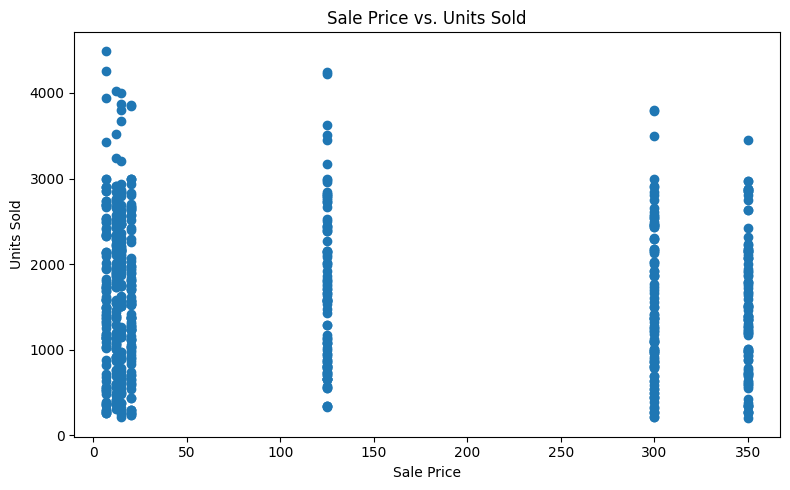

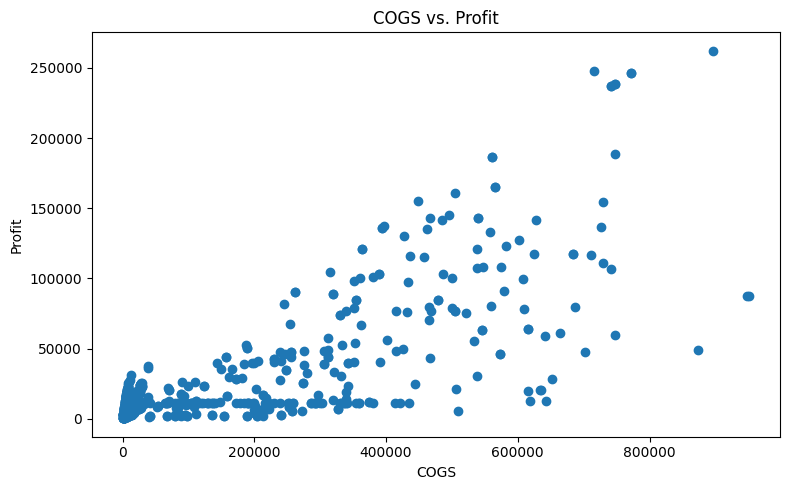

In [9]:
if 'sale_price' in df.columns and 'units_sold' in df.columns:
    plt.figure(figsize=(8, 5))
    plt.scatter(df['sale_price'], df['units_sold'])
    plt.title('Sale Price vs. Units Sold')
    plt.xlabel('Sale Price')
    plt.ylabel('Units Sold')
    plt.tight_layout()
    plt.show()

if 'cogs' in df.columns and 'profit' in df.columns:
    plt.figure(figsize=(8, 5))
    plt.scatter(df['cogs'], df['profit'])
    plt.title('COGS vs. Profit')
    plt.xlabel('COGS')
    plt.ylabel('Profit')
    plt.tight_layout()
    plt.show()


## Step 8 – Boxplot: Profit by Segment

This boxplot shows the distribution of profit for each segment.


<Figure size 800x500 with 0 Axes>

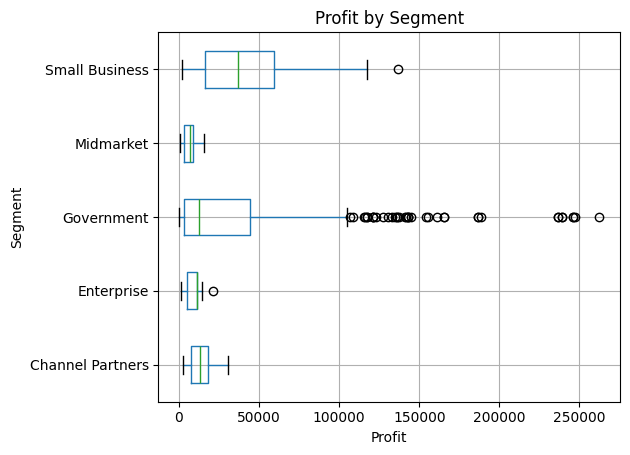

In [10]:
if 'segment' in df.columns and 'profit' in df.columns:
    plt.figure(figsize=(8, 5))
    df.boxplot(column='profit', by='segment', vert=False)
    plt.title('Profit by Segment')
    plt.suptitle('')  # Remove the default suptitle
    plt.xlabel('Profit')
    plt.ylabel('Segment')
    plt.tight_layout()
    plt.show()


## Step 9 – Correlation Matrix with Values

We compute the correlation matrix for numeric variables and display it as a heatmap with the numerical values annotated.



Correlation Matrix:
                     units_sold  manufacturing_price  sale_price  gross_sales  \
units_sold             1.000000            -0.029644   -0.065066     0.327221   
manufacturing_price   -0.029644             1.000000    0.070786     0.049852   
sale_price            -0.065066             0.070786    1.000000     0.808250   
gross_sales            0.327221             0.049852    0.808250     1.000000   
discounts              0.254591             0.020283    0.643111     0.785280   
sales                  0.326914             0.051549    0.805878     0.998174   
cogs                   0.331694             0.046857    0.799335     0.994519   
profit                 0.258348             0.066517    0.675166     0.824404   

                     discounts     sales      cogs    profit  
units_sold            0.254591  0.326914  0.331694  0.258348  
manufacturing_price   0.020283  0.051549  0.046857  0.066517  
sale_price            0.643111  0.805878  0.799335  0.675166

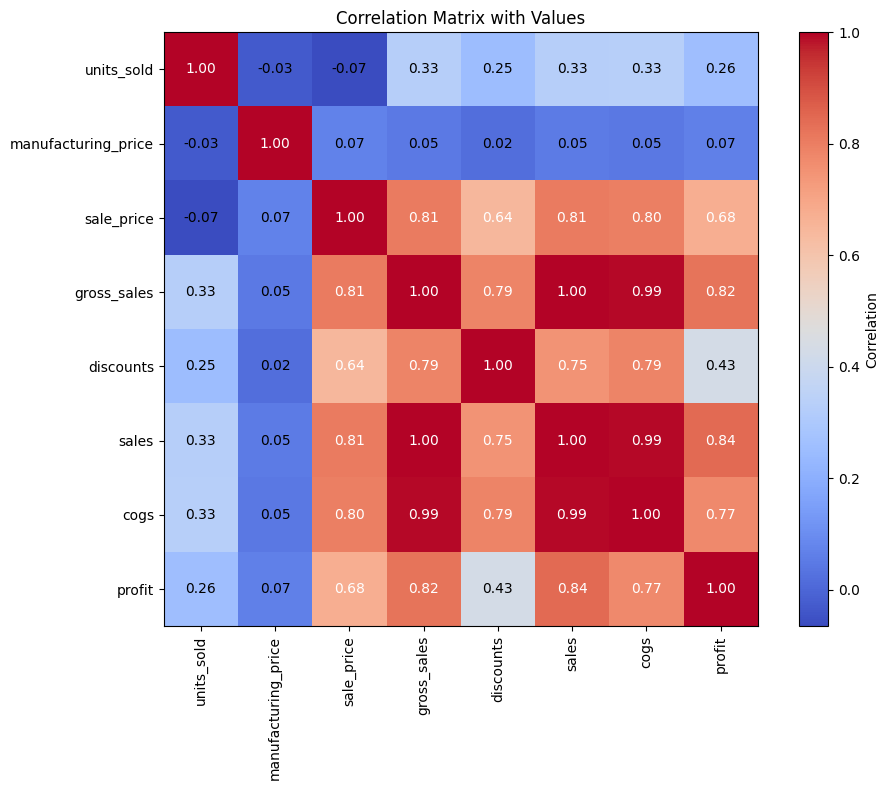

In [11]:
corr_matrix = df[numeric_columns].corr()
print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar(im, label='Correlation')
plt.title('Correlation Matrix with Values')
plt.xticks(ticks=range(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=90)
plt.yticks(ticks=range(len(corr_matrix.index)), labels=corr_matrix.index)

threshold = np.nanmax(corr_matrix.values) / 2.0
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        value = corr_matrix.iloc[i, j]
        color = "white" if value > threshold else "black"
        plt.text(j, i, f"{value:.2f}", ha='center', va='center', color=color)
plt.tight_layout()
plt.show()


## Step 10 – Pie Chart: Distribution by Segment

The following pie chart shows the relative distribution of companies by segment.


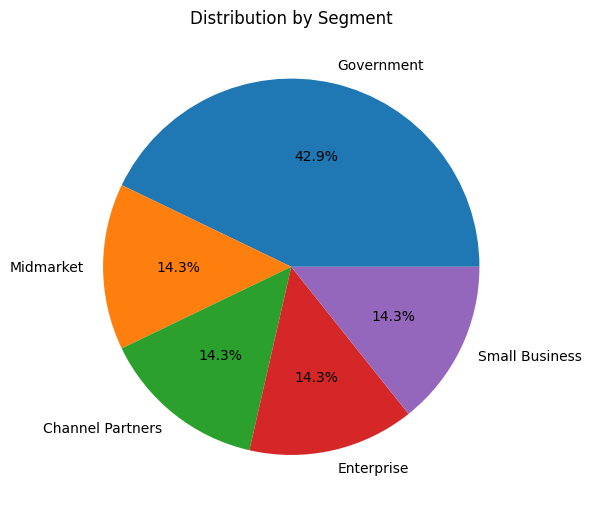

In [12]:
if 'segment' in df.columns:
    segment_counts = df['segment'].value_counts()
    plt.figure(figsize=(6, 6))
    plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%')
    plt.title('Distribution by Segment')
    plt.tight_layout()
    plt.show()


## Additional Plots

Below are additional visualizations as requested:
- **A. Combined Line Chart:** Sales and Profit over time (monthly data).
- **B. Heatmap of Units Sold (Products vs. Segments)**
- **C. Heatmap of Units Sold (Products vs. Discount Bands)**
- **D. Heatmap of Profit (Segments vs. Discount Bands)**
- **E. Heatmap of Profit (Products vs. Discount Bands)**


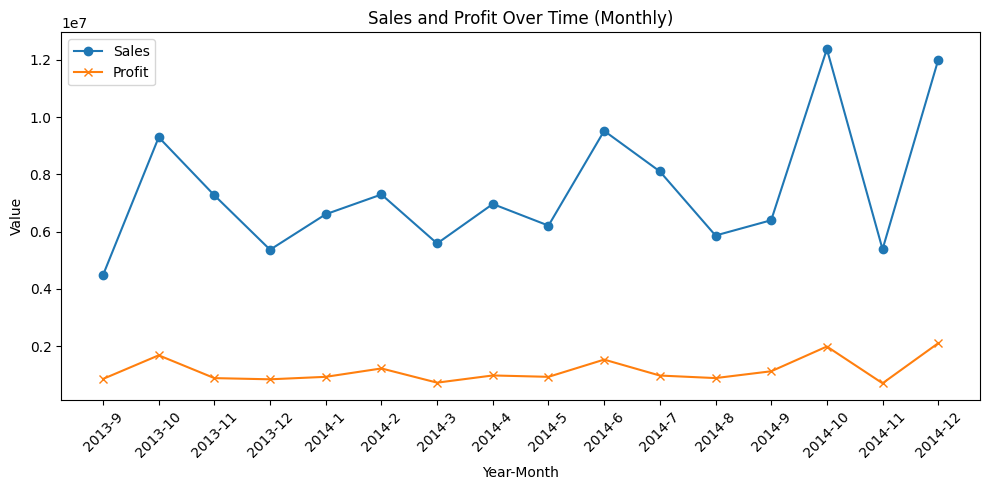

In [13]:
if 'year' in df.columns and 'month_number' in df.columns and 'sales' in df.columns and 'profit' in df.columns:
    monthly_data = df.groupby(['year', 'month_number'])[['sales', 'profit']].sum().reset_index()
    monthly_data.sort_values(['year', 'month_number'], inplace=True)
    monthly_data['year_month'] = monthly_data['year'].astype(str) + '-' + monthly_data['month_number'].astype(str)

    plt.figure(figsize=(10, 5))
    plt.plot(monthly_data['year_month'], monthly_data['sales'], marker='o', label='Sales')
    plt.plot(monthly_data['year_month'], monthly_data['profit'], marker='x', label='Profit')
    plt.title('Sales and Profit Over Time (Monthly)')
    plt.xlabel('Year-Month')
    plt.ylabel('Value')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


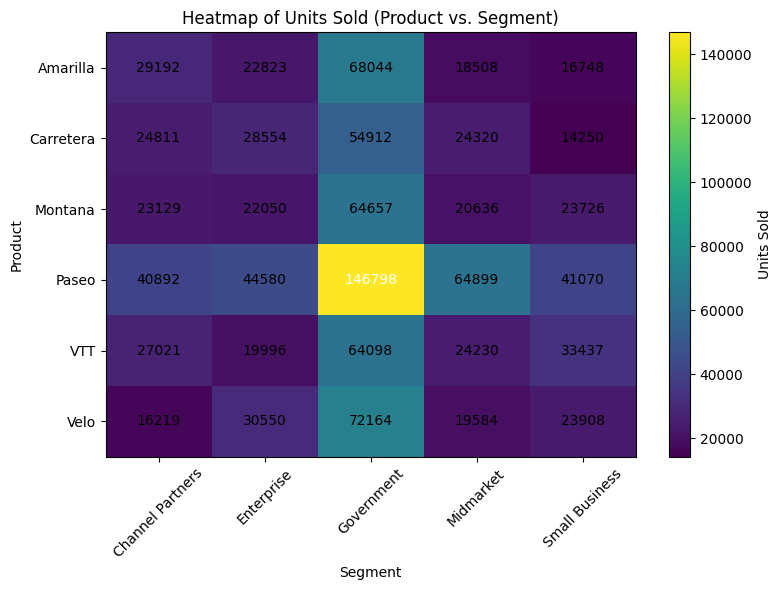

In [14]:
if 'product' in df.columns and 'segment' in df.columns and 'units_sold' in df.columns:
    pivot_units_ps = df.pivot_table(values='units_sold', index='product', columns='segment', aggfunc='sum')
    pivot_units_ps = pivot_units_ps.fillna(0)

    plt.figure(figsize=(8, 6))
    im = plt.imshow(pivot_units_ps, aspect='auto', cmap='viridis')
    plt.colorbar(im, label='Units Sold')
    plt.title('Heatmap of Units Sold (Product vs. Segment)')
    plt.xlabel('Segment')
    plt.ylabel('Product')
    plt.xticks(ticks=range(len(pivot_units_ps.columns)), labels=pivot_units_ps.columns, rotation=45)
    plt.yticks(ticks=range(len(pivot_units_ps.index)), labels=pivot_units_ps.index)
    
    threshold = pivot_units_ps.values.max() / 2.0
    for i in range(pivot_units_ps.shape[0]):
        for j in range(pivot_units_ps.shape[1]):
            value = pivot_units_ps.iloc[i, j]
            color = "white" if value > threshold else "black"
            plt.text(j, i, f'{value:.0f}', ha='center', va='center', color=color)
    plt.tight_layout()
    plt.show()


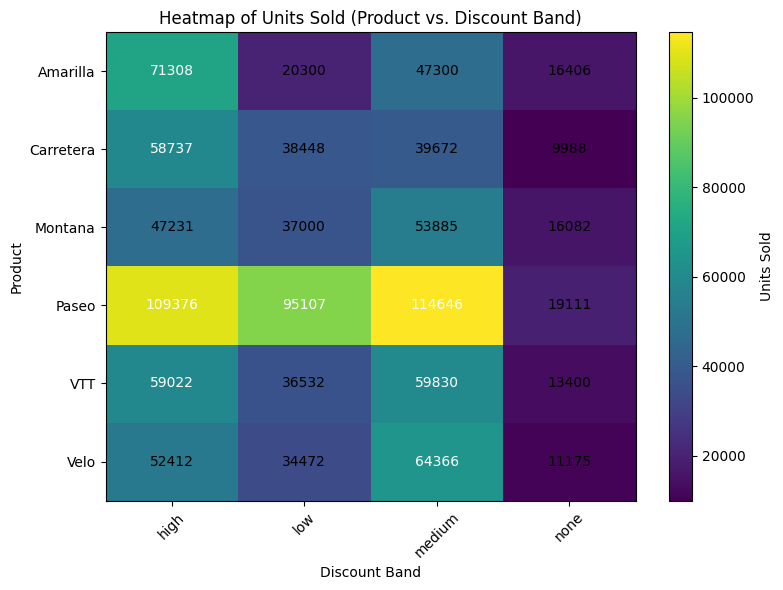

In [15]:
if 'product' in df.columns and 'discount_band' in df.columns and 'units_sold' in df.columns:
    pivot_units_pd = df.pivot_table(values='units_sold', index='product', columns='discount_band', aggfunc='sum')
    pivot_units_pd = pivot_units_pd.fillna(0)

    plt.figure(figsize=(8, 6))
    im = plt.imshow(pivot_units_pd, aspect='auto', cmap='viridis')
    plt.colorbar(im, label='Units Sold')
    plt.title('Heatmap of Units Sold (Product vs. Discount Band)')
    plt.xlabel('Discount Band')
    plt.ylabel('Product')
    plt.xticks(ticks=range(len(pivot_units_pd.columns)), labels=pivot_units_pd.columns, rotation=45)
    plt.yticks(ticks=range(len(pivot_units_pd.index)), labels=pivot_units_pd.index)
    
    threshold = pivot_units_pd.values.max() / 2.0
    for i in range(pivot_units_pd.shape[0]):
        for j in range(pivot_units_pd.shape[1]):
            value = pivot_units_pd.iloc[i, j]
            color = "white" if value > threshold else "black"
            plt.text(j, i, f'{value:.0f}', ha='center', va='center', color=color)
    plt.tight_layout()
    plt.show()


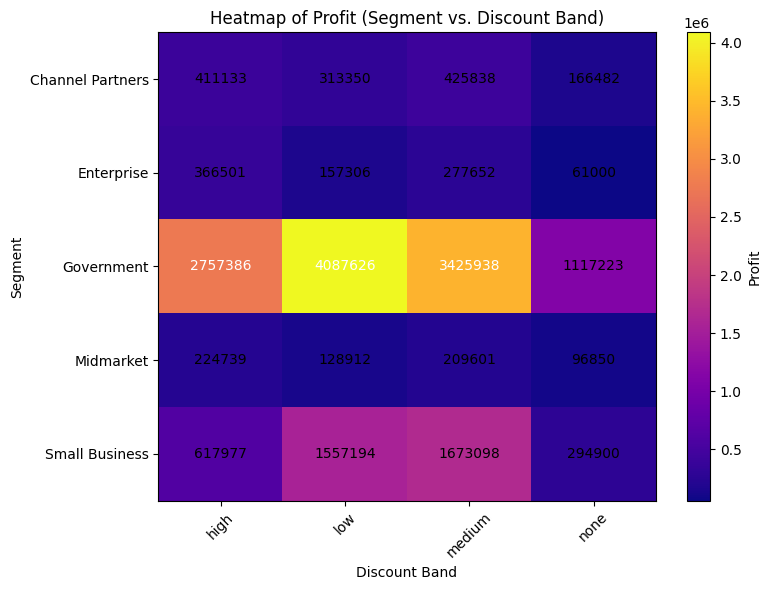

In [16]:
if 'segment' in df.columns and 'discount_band' in df.columns and 'profit' in df.columns:
    pivot_profit_sd = df.pivot_table(values='profit', index='segment', columns='discount_band', aggfunc='sum')
    pivot_profit_sd = pivot_profit_sd.fillna(0)

    plt.figure(figsize=(8, 6))
    im = plt.imshow(pivot_profit_sd, aspect='auto', cmap='plasma')
    plt.colorbar(im, label='Profit')
    plt.title('Heatmap of Profit (Segment vs. Discount Band)')
    plt.xlabel('Discount Band')
    plt.ylabel('Segment')
    plt.xticks(ticks=range(len(pivot_profit_sd.columns)), labels=pivot_profit_sd.columns, rotation=45)
    plt.yticks(ticks=range(len(pivot_profit_sd.index)), labels=pivot_profit_sd.index)
    
    threshold = pivot_profit_sd.values.max() / 2.0
    for i in range(pivot_profit_sd.shape[0]):
        for j in range(pivot_profit_sd.shape[1]):
            value = pivot_profit_sd.iloc[i, j]
            color = "white" if value > threshold else "black"
            plt.text(j, i, f'{value:.0f}', ha='center', va='center', color=color)
    plt.tight_layout()
    plt.show()


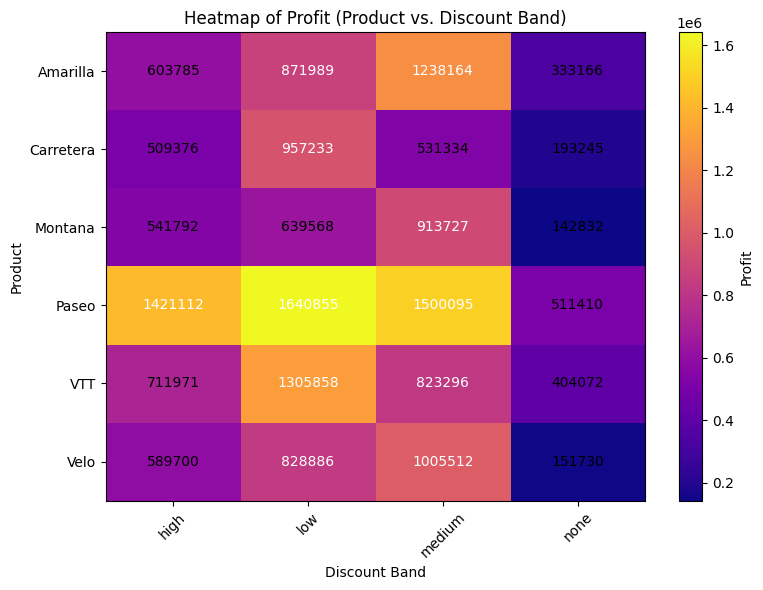

In [17]:
if 'product' in df.columns and 'discount_band' in df.columns and 'profit' in df.columns:
    pivot_profit_pd = df.pivot_table(values='profit', index='product', columns='discount_band', aggfunc='sum')
    pivot_profit_pd = pivot_profit_pd.fillna(0)

    plt.figure(figsize=(8, 6))
    im = plt.imshow(pivot_profit_pd, aspect='auto', cmap='plasma')
    plt.colorbar(im, label='Profit')
    plt.title('Heatmap of Profit (Product vs. Discount Band)')
    plt.xlabel('Discount Band')
    plt.ylabel('Product')
    plt.xticks(ticks=range(len(pivot_profit_pd.columns)), labels=pivot_profit_pd.columns, rotation=45)
    plt.yticks(ticks=range(len(pivot_profit_pd.index)), labels=pivot_profit_pd.index)
    
    threshold = pivot_profit_pd.values.max() / 2.0
    for i in range(pivot_profit_pd.shape[0]):
        for j in range(pivot_profit_pd.shape[1]):
            value = pivot_profit_pd.iloc[i, j]
            color = "white" if value > threshold else "black"
            plt.text(j, i, f'{value:.0f}', ha='center', va='center', color=color)
    plt.tight_layout()
    plt.show()


## Conclusion

We have performed an extensive Exploratory Data Analysis on the cleaned dataset.  
The notebook includes:
- Categorical and numeric variable distributions,
- Bar charts for average profit and total sales,
- Sales and profit evolution over time,
- Scatter plots and boxplots,
- A correlation matrix annotated with values,
- Pie chart for segment distribution,
- Additional combined line charts and heatmaps for sales and profit by products/segments/discount bands.

The next steps could be further feature engineering, modeling or clustering based on these insights.


In [ ]:
new_ratio_cols = ['roa', 'roe', 'marge_nette', 'endettement', 'liquidite', 'rotation_actifs']

for col in new_ratio_cols:
    if col in df.columns:
        data = df[col].dropna()
        plt.figure(figsize=(8, 5))
        rng = data.max() - data.min()
        # Si le nombre de valeurs uniques est inférieur à 5 ou la plage est très faible,
        # on affiche un diagramme à barres pour mieux représenter la distribution.
        if data.nunique() < 5 or rng < 1e-4:
            counts = data.value_counts().sort_index()
            plt.bar(counts.index.astype(str), counts.values, color='skyblue', edgecolor='k')
            plt.title(f'Bar Plot de {col} (données quasi-constantes)')
            plt.xlabel(col)
            plt.ylabel("Nombre d'observations")
        else:
            plt.hist(data, bins='auto', edgecolor='k')
            plt.title(f'Histogramme de {col}')
            plt.xlabel(col)
            plt.ylabel('Fréquence')
        plt.tight_layout()
        plt.show()
